##Import Libaraies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler


##Load dataset

In [ ]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


##Data understanding

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


##Check Missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


There is none missing values so now we move on to checking duplicated values

In [ ]:
df.duplicated().sum()

np.int64(1)

only one duplicated value was found

In [ ]:
df=df.drop_duplicates()
df.shape

(1337, 7)

#Visualization

##Histogram:

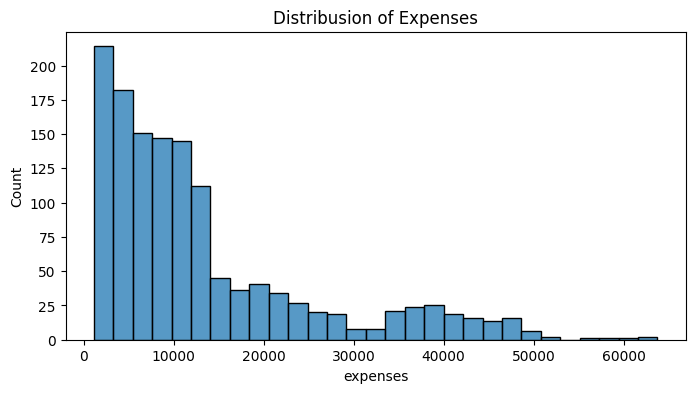

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(x="expenses",data=df)
plt.title("Distribusion of Expenses")
plt.show()

As it shown in the distribusion of expenses theres skewness to the right

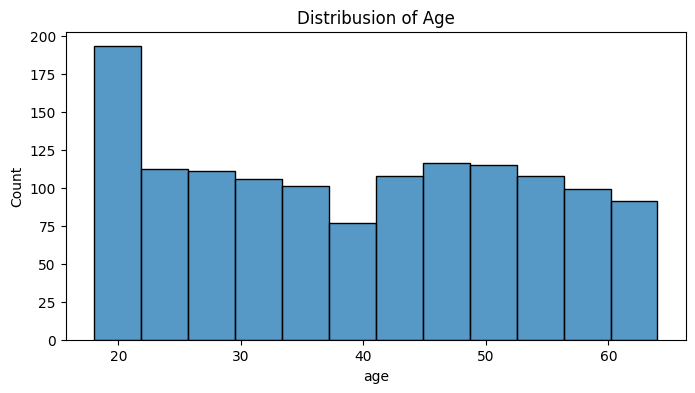

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(x="age",data=df)
plt.title("Distribusion of Age")
plt.show()

In this histogram the distribusion seems fairly even

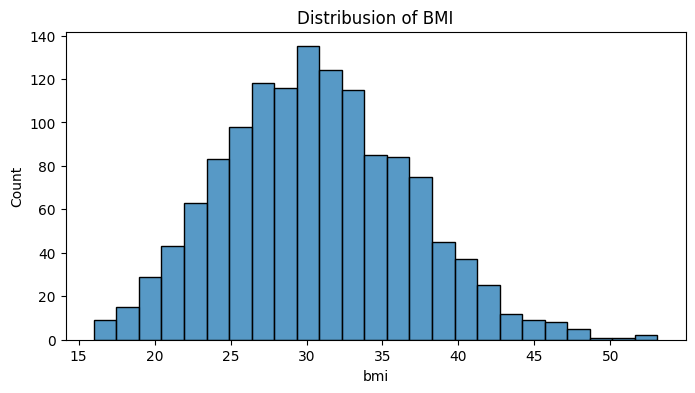

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(x="bmi",data=df)
plt.title("Distribusion of BMI")
plt.show()

As it shown in this histogram the distribusion is normal

##ScatterPlot:

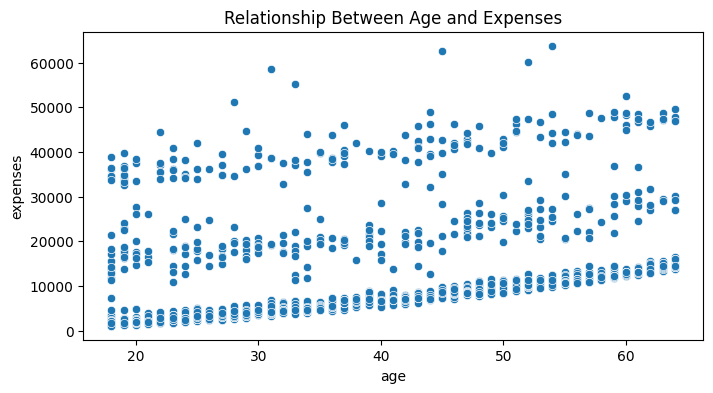

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(x="age",y="expenses",data=df)
plt.title("Relationship Between Age and Expenses")
plt.show()

It shows a positive relationship between age and expenses

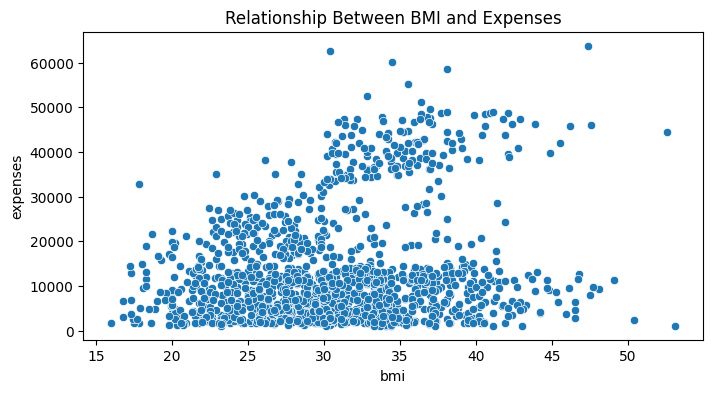

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(x="bmi",y="expenses",data=df)
plt.title("Relationship Between BMI and Expenses")
plt.show()

This scatterplot also shows a positive relationship between bmi and expenses but not as strong as the one with age.

##Boxplot:

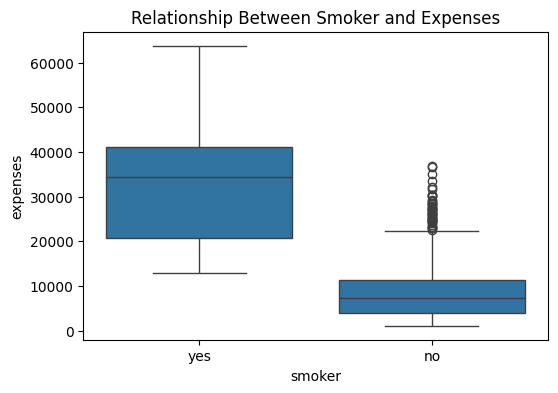

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker",y="expenses",data=df)
plt.title("Relationship Between Smoker and Expenses")
plt.show()

Smokers have much higher medical expenses than non-smokers.

Non-smokers also have several high-expense outliers.

##Correlation

In [ ]:
df_encoded=df.copy()
df_encoded["sex"]=df_encoded["sex"].map({"male":1,"female":0})
df_encoded["smoker"]=df_encoded["smoker"].map({"yes":1,"no":0})
df_encoded=pd.get_dummies(df_encoded,columns=["region"],drop_first=True)

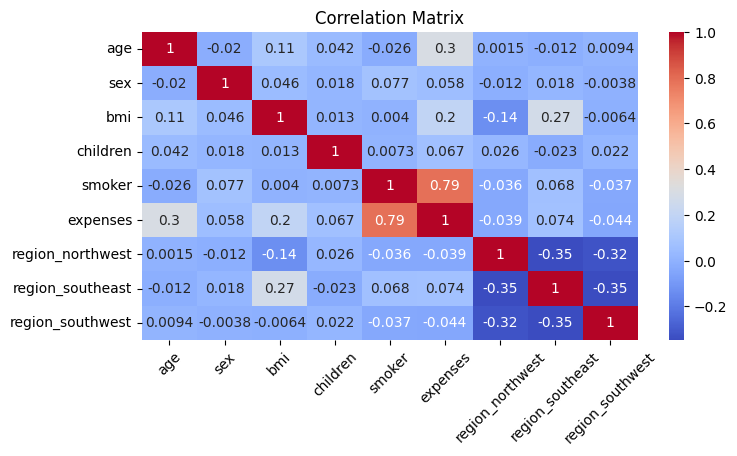

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df_encoded.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

As it shows in the heatmap the strongest relationship with our target variable is smoker

And also there is a moderate positive correlation between age and expenses

Unlike the correlation between bmi and expenses

#Algorithm

In [ ]:
X = df_encoded.drop("expenses", axis=1)
y = df_encoded["expenses"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 8)
Testing data: (268, 8)


# Lasso Regression (L1)

## What is Lasso Regression?
Lasso Regression is a regularized version of Linear Regression that adds an L1 penalty to shrink some coefficients to zero.

## How does it work?
It minimizes the prediction error while adding a penalty based on the absolute values of the coefficients.

## When should it be used?
- When the dataset contains many features.
- When feature selection is needed.
- When overfitting needs to be reduced.

## Advantages
- Reduces overfitting.
- Performs feature selection.
- Produces a simpler model.

## Limitations
- May remove useful features.
- Performance depends on the alpha value.

##Train

In [ ]:
lasso_model = Lasso(alpha=1, max_iter=10000)
lasso_model.fit(X_train, y_train)

Lasso(alpha=1, max_iter=10000)

##Prediction

In [ ]:
lasso_pred = lasso_model.predict(X_test)

##Evaluation

In [ ]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Ridge Regression (L2)

## What is Ridge Regression?
Ridge Regression is a regularized version of Linear Regression that adds an L2 penalty to reduce large coefficients and prevent overfitting.

## How does it work?
It minimizes the prediction error while adding a penalty based on the squared values of the coefficients.

## When should it be used?
- When the dataset has many correlated features.
- When overfitting is a concern.
- When all features are expected to contribute to the prediction.

## Advantages
- Reduces overfitting.
- Keeps all features.
- Works well with multicollinearity.

## Limitations
- Does not perform feature selection.
- Choosing the regularization parameter (alpha) is important.

##Train

In [ ]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)

Ridge(alpha=1)

##Prediction

In [ ]:
ridge_pred = ridge_model.predict(X_test)

##Evaluation

In [ ]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# Elastic Net Regression

## What is Elastic Net?
Elastic Net is a regularized version of Linear Regression that combines both L1 (Lasso) and L2 (Ridge) penalties.

## How does it work?
It minimizes the prediction error while applying both L1 and L2 regularization to the model coefficients.

## When should it be used?
- When the dataset has many correlated features.
- When feature selection and regularization are both needed.
- When Lasso or Ridge alone does not provide the best performance.

## Advantages
- Combines the strengths of Ridge and Lasso.
- Reduces overfitting.
- Can perform feature selection while keeping correlated features.

## Limitations
- Requires tuning two parameters (alpha and l1_ratio).
- More complex than Ridge or Lasso alone.

##Train

In [ ]:
elastic_model = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=10000)
elastic_model.fit(X_train, y_train)

ElasticNet(alpha=1, max_iter=10000)

##Prediction

In [ ]:
elastic_pred = elastic_model.predict(X_test)

##Evalution

In [ ]:
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_pred)

# Initial Model Comparison


In [ ]:
initial_comparison = pd.DataFrame({
    "Model": ["Ridge (L2)", "Lasso (L1)", "Elastic Net"],
    "MAE": [ridge_mae, lasso_mae, elastic_mae],
    "MSE": [ridge_mse, lasso_mse, elastic_mse],
    "RMSE": [ridge_rmse, lasso_rmse, elastic_rmse],
    "R²": [ridge_r2, lasso_r2, elastic_r2]
})

initial_comparison.round(2)

,Model,MAE,MSE,RMSE,R²
0,Ridge (L2),4194.23,3.566025e+07,5971.62,0.81
1,Lasso (L1),4178.12,3.549445e+07,5957.72,0.81
2,Elastic Net,7860.26,1.115534e+08,10561.89,0.39


# Model Improvement

## Note About the Initial Result

After comparing the models using MAE, MSE, RMSE, and R², we noticed that Elastic Net performed much worse than Ridge and Lasso.

The first Elastic Net model used fixed values:

- `alpha = 1`
- `l1_ratio = 0.5`

The features were also not scaled. This can affect regularized models because the penalty depends on the size of the feature values.

To improve the models, we:

1. Standardized the features using `StandardScaler`.
2. Used `GridSearchCV` to test different values of `alpha`.
3. Tested different values of `l1_ratio` for Elastic Net.
4. Used 5-fold cross-validation to select the best parameters.

We applied the same improvement process to all three models to make the comparison fair.


## Feature Scaling


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Improved Lasso Regression


In [ ]:
lasso_params = {
    "alpha": [0.1, 1, 5, 10, 50, 100, 300]
}

lasso_cv = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring="r2"
)

lasso_cv.fit(X_train_scaled, y_train)

improved_lasso = lasso_cv.best_estimator_

print("Best Lasso parameters:", lasso_cv.best_params_)


Best Lasso parameters: {'alpha': 50}


In [ ]:
improved_lasso_pred = improved_lasso.predict(X_test_scaled)

improved_lasso_mae = mean_absolute_error(y_test, improved_lasso_pred)
improved_lasso_mse = mean_squared_error(y_test, improved_lasso_pred)
improved_lasso_rmse = np.sqrt(improved_lasso_mse)
improved_lasso_r2 = r2_score(y_test, improved_lasso_pred)


## Improved Ridge Regression


In [ ]:
ridge_params = {
    "alpha": [0.01, 0.1, 1, 5, 10, 50, 100]
}

ridge_cv = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_cv.fit(X_train_scaled, y_train)

improved_ridge = ridge_cv.best_estimator_

print("Best Ridge parameters:", ridge_cv.best_params_)


Best Ridge parameters: {'alpha': 10}


In [ ]:
improved_ridge_pred = improved_ridge.predict(X_test_scaled)

improved_ridge_mae = mean_absolute_error(y_test, improved_ridge_pred)
improved_ridge_mse = mean_squared_error(y_test, improved_ridge_pred)
improved_ridge_rmse = np.sqrt(improved_ridge_mse)
improved_ridge_r2 = r2_score(y_test, improved_ridge_pred)


## Improved Elastic Net Regression


In [ ]:
elastic_params = {
    "alpha": [0.01, 0.1, 1, 5, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_cv = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_params,
    cv=5,
    scoring="r2"
)

elastic_cv.fit(X_train_scaled, y_train)

improved_elastic = elastic_cv.best_estimator_

print("Best Elastic Net parameters:", elastic_cv.best_params_)


Best Elastic Net parameters: {'alpha': 0.1, 'l1_ratio': 0.9}


In [ ]:
improved_elastic_pred = improved_elastic.predict(X_test_scaled)

improved_elastic_mae = mean_absolute_error(y_test, improved_elastic_pred)
improved_elastic_mse = mean_squared_error(y_test, improved_elastic_pred)
improved_elastic_rmse = np.sqrt(improved_elastic_mse)
improved_elastic_r2 = r2_score(y_test, improved_elastic_pred)


# Improved Model Comparison


In [ ]:
improved_comparison = pd.DataFrame({
    "Model": ["Ridge (L2)", "Lasso (L1)", "Elastic Net"],
    "MAE": [
        improved_ridge_mae,
        improved_lasso_mae,
        improved_elastic_mae
    ],
    "MSE": [
        improved_ridge_mse,
        improved_lasso_mse,
        improved_elastic_mse
    ],
    "RMSE": [
        improved_ridge_rmse,
        improved_lasso_rmse,
        improved_elastic_rmse
    ],
    "R²": [
        improved_ridge_r2,
        improved_lasso_r2,
        improved_elastic_r2
    ]
})

improved_comparison.round(2)


,Model,MAE,MSE,RMSE,R²
0,Ridge (L2),4202.80,35832181.27,5986.00,0.81
1,Lasso (L1),4186.96,35886762.93,5990.56,0.80
2,Elastic Net,4204.56,35857577.19,5988.12,0.80


# Before and After Improvement


In [ ]:
before_after = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "Initial R²": [ridge_r2, lasso_r2, elastic_r2],
    "Improved R²": [
        improved_ridge_r2,
        improved_lasso_r2,
        improved_elastic_r2
    ],
    "Initial RMSE": [ridge_rmse, lasso_rmse, elastic_rmse],
    "Improved RMSE": [
        improved_ridge_rmse,
        improved_lasso_rmse,
        improved_elastic_rmse
    ]
})

before_after.round(2)


,Model,Initial R²,Improved R²,Initial RMSE,Improved RMSE
0,Ridge,0.81,0.81,5971.62,5986.00
1,Lasso,0.81,0.80,5957.72,5990.56
2,Elastic Net,0.39,0.80,10561.89,5988.12


We used both R² and RMSE to compare the models because both metrics are important. R² shows how well the model explains the variation in medical expenses, while RMSE shows the size of the prediction error in the same unit as expenses. The best model should have the highest R² score and the lowest RMSE.


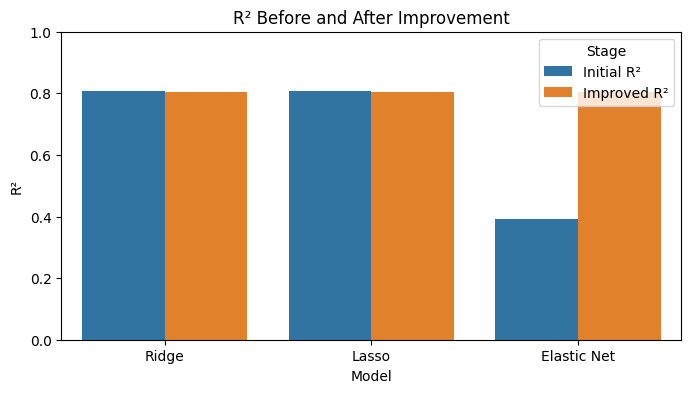

In [ ]:
comparison_plot = before_after.melt(
    id_vars="Model",
    value_vars=["Initial R²", "Improved R²"],
    var_name="Stage",
    value_name="R²"
)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_plot, x="Model", y="R²", hue="Stage")
plt.title("R² Before and After Improvement")
plt.ylim(0, 1)
plt.show()


# Final Conclusion

At first, Elastic Net had a lower performance because we used fixed parameter values and the features were not scaled.

After applying feature scaling and GridSearchCV, the model was able to select better values for `alpha` and `l1_ratio`. This improved the Elastic Net result and made the comparison between Ridge, Lasso, and Elastic Net more reliable.

The final best model should be selected by looking for:

- The highest R² score.
- The lowest MAE, MSE, and RMSE.

The EDA also showed that smoking status has the strongest relationship with medical expenses. Age and BMI also have positive relationships with expenses.
